1. Setup Awal

In [8]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Mengunduh dan Memuat Data MNIST

In [9]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

3. Eksplorasi Data

Bentuk data X: (70000, 784)
Bentuk data y: (70000,)


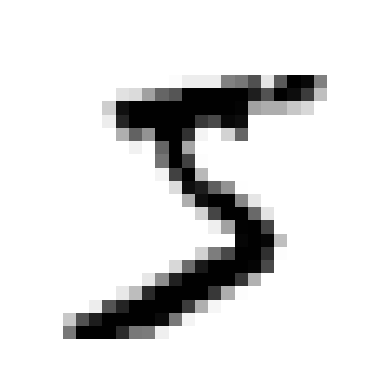

Label untuk digit di atas: 5


In [10]:
# Melihat bentuk (dimensi) data
print("Bentuk data X:", X.shape)
print("Bentuk data y:", y.shape)

# Mengambil satu contoh data (sebuah digit)
some_digit = X.iloc[0] # Menggunakan .iloc untuk mengakses baris berdasarkan posisi integer
some_digit_image = some_digit.values.reshape(28, 28) # Mengubah vektor menjadi matriks 28x28

# Menampilkan gambar digit tersebut
plt.imshow(some_digit_image, cmap=mpl.cm.binary)
plt.axis("off")
plt.show()

# Melihat label dari digit tersebut
print("Label untuk digit di atas:", y[0])

# Mengubah tipe data label dari string menjadi integer
y = y.astype(np.uint8)

4. Mempersiapkan Data (Train/Test Split & Klasifikasi Biner)

In [11]:
# Data MNIST sudah terbagi menjadi train dan test set
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

# Membuat target untuk masalah klasifikasi biner: "Angka 5" atau "Bukan Angka 5"
y_train_5 = (y_train == 5)
y_test_5 = (y_test == 5)

5. Melatih Model Klasifikasi Biner (SGD)

In [12]:
from sklearn.linear_model import SGDClassifier

# Membuat model Stochastic Gradient Descent Classifier
sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# Melatih model
sgd_clf.fit(X_train, y_train_5)

# Melakukan prediksi pada satu contoh digit
print("Prediksi model untuk digit 5:", sgd_clf.predict([some_digit]))

Prediksi model untuk digit 5: [ True]


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


 6. Mengukur Performa dengan Cross-Validation & Confusion Matrix

In [13]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix

# Mendapatkan prediksi untuk setiap data di set pelatihan menggunakan cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

# Membuat confusion matrix
cm = confusion_matrix(y_train_5, y_train_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]


7. Precision, Recall, dan F1-Score

In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Menghitung precision
precision = precision_score(y_train_5, y_train_pred)
print("Precision:", precision)

# Menghitung recall
recall = recall_score(y_train_5, y_train_pred)
print("Recall:", recall)

# Menghitung F1-score
f1 = f1_score(y_train_5, y_train_pred)
print("F1 Score:", f1)

Precision: 0.8370879772350012
Recall: 0.6511713705958311
F1 Score: 0.7325171197343847


 8. Kurva Precision-Recall dan ROC

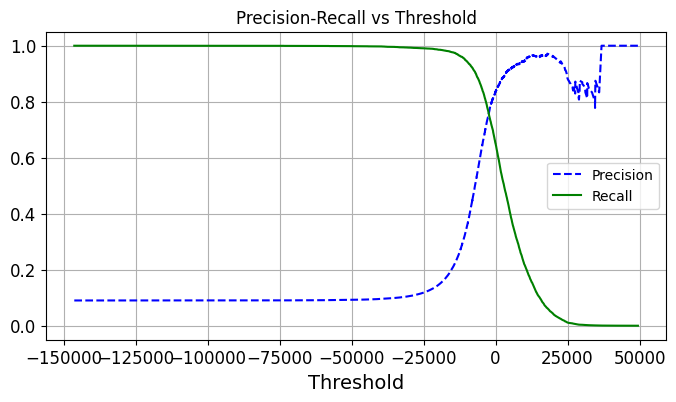

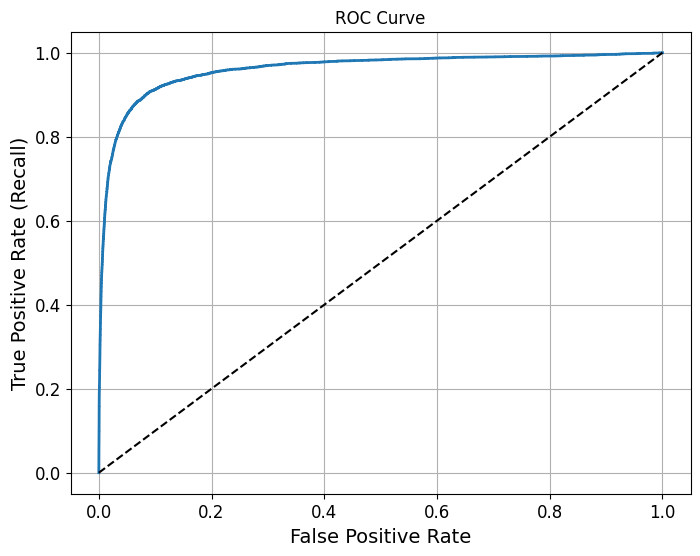

AUC Score: 0.9604938554008616


In [15]:
from sklearn.metrics import precision_recall_curve, roc_curve, roc_auc_score

# Mendapatkan decision scores
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

# 1. Kurva Precision-Recall
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
plt.legend()
plt.xlabel("Threshold")
plt.grid(True)
plt.title("Precision-Recall vs Threshold")
plt.show()

# 2. Kurva ROC (Receiver Operating Characteristic)
fpr, tpr, thresholds_roc = roc_curve(y_train_5, y_scores)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label="SGD")
plt.plot([0, 1], [0, 1], 'k--') # Garis acak (random)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.grid(True)
plt.title("ROC Curve")
plt.show()

# Menghitung skor AUC (Area Under the Curve)
auc_score = roc_auc_score(y_train_5, y_scores)
print("AUC Score:", auc_score)

9. Perbandingan Model (Random Forest)

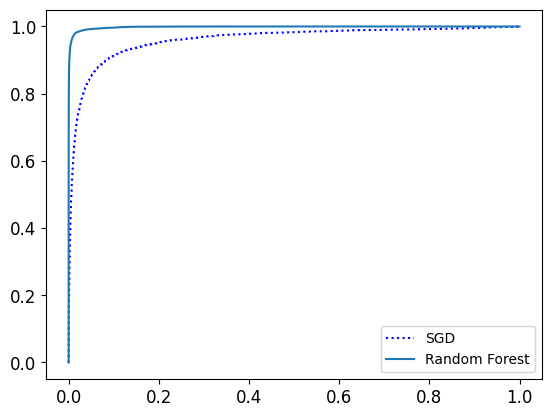

AUC Score (Random Forest): 0.9983436731328145


In [16]:
from sklearn.ensemble import RandomForestClassifier

# Melatih model Random Forest
forest_clf = RandomForestClassifier(n_estimators=100, random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")
y_scores_forest = y_probas_forest[:, 1] # probabilitas kelas positif

# Menghitung dan memplot kurva ROC untuk Random Forest
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5, y_scores_forest)
plt.plot(fpr, tpr, "b:", label="SGD")
plt.plot(fpr_forest, tpr_forest, label="Random Forest")
plt.legend(loc="lower right")
plt.show()

# Menghitung skor AUC untuk Random Forest
auc_forest = roc_auc_score(y_train_5, y_scores_forest)
print("AUC Score (Random Forest):", auc_forest)

10. Klasifikasi Multiclass

In [18]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score # Import cross_val_score

# Melatih model pada semua 10 kelas (0-9)
sgd_clf.fit(X_train, y_train)
print("Prediksi model untuk digit 5 (multiclass):", sgd_clf.predict([some_digit]))

# Menampilkan skor cross-validation untuk akurasi
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype(np.float64))
accuracy_scores = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")
print("\nSkor Akurasi (Cross-Validation):", accuracy_scores)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but SGDClassifier was fitted with feature names
  warnings.warn(


Prediksi model untuk digit 5 (multiclass): [3]

Skor Akurasi (Cross-Validation): [0.8983 0.891  0.9018]


 11. Analisis Error

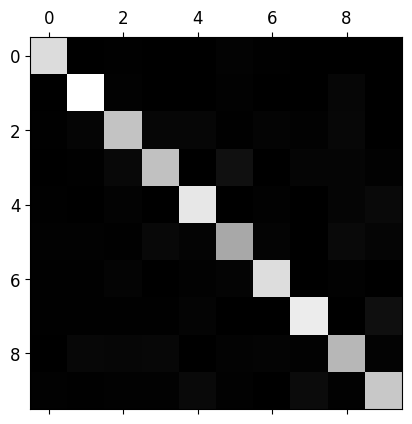

In [21]:
# Ambil 10,000 data pertama saja untuk mempercepat
X_train_small = X_train_scaled[:5000]
y_train_small = y_train[:5000]

# Jalankan cross_val_predict pada data yang lebih kecil
# Ini akan jauh lebih cepat
y_train_pred_small = cross_val_predict(sgd_clf, X_train_small, y_train_small, cv=3)

# Buat confusion matrix dari hasil data kecil
conf_mx = confusion_matrix(y_train_small, y_train_pred_small)

# Lanjutkan dengan plotting...
plt.matshow(conf_mx, cmap=plt.cm.gray)
plt.show()

12. Klasifikasi Multilabel

In [22]:
from sklearn.neighbors import KNeighborsClassifier

# Membuat dua label untuk setiap data: apakah digitnya besar (>=7) dan apakah ganjil
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

# Melatih model KNN untuk klasifikasi multilabel
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

# Prediksi pada satu digit (angka 5)
print("Prediksi Multilabel untuk digit 5:", knn_clf.predict([some_digit]))

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Prediksi Multilabel untuk digit 5: [[False  True]]


13. Klasifikasi Multioutput (Membersihkan Gambar)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


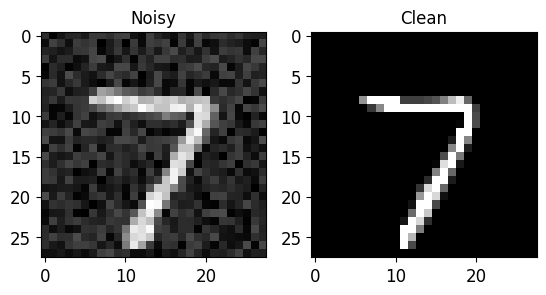

In [24]:
# Menambahkan noise acak ke gambar digit
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train # Targetnya adalah gambar asli yang bersih
y_test_mod = X_test

# Melatih model untuk "membersihkan" gambar
knn_clf.fit(X_train_mod, y_train_mod)

# Mengambil satu digit yang sudah diberi noise dan membersihkannya
some_index = 0
clean_digit = knn_clf.predict([X_test_mod.iloc[some_index]])

# Menampilkan gambar yang ber-noise dan gambar hasil pembersihan
plt.subplot(121); plt.imshow(X_test_mod.iloc[some_index].values.reshape(28, 28), cmap="gray"); plt.title("Noisy")
plt.subplot(122); plt.imshow(clean_digit.reshape(28, 28), cmap="gray"); plt.title("Clean")
plt.show()

Penjelasan Kode
Bagian 1 & 2. Setup dan Mengunduh Data: Bagian ini melakukan persiapan standar dan mengunduh dataset MNIST. MNIST adalah dataset "hello world" untuk machine learning, berisi 70.000 gambar tulisan tangan angka dari 0 hingga 9.

Bagian 3. Eksplorasi Data: Sebelum melakukan apapun, kita perlu "mengintip" data kita. .shape menunjukkan ada 70.000 gambar, masing-masing dengan 784 fitur (karena gambar berukuran 28x28 piksel, dan 28*28=784). Kita juga menampilkan satu gambar untuk memastikan datanya benar.

Bagian 4. Persiapan Klasifikasi Biner: Untuk memahami konsep evaluasi klasifikasi, masalahnya disederhanakan. Daripada langsung mengklasifikasikan 10 angka, kita membuat masalah biner (dua kelas): apakah sebuah gambar adalah "angka 5" atau "bukan angka 5".

Bagian 5. Melatih Model Klasifikasi Biner: Kita menggunakan SGDClassifier (Stochastic Gradient Descent), sebuah model yang efisien untuk dataset besar. Proses .fit() adalah saat model "belajar" pola yang membedakan antara angka 5 dan bukan angka 5.

Bagian 6. Confusion Matrix: Akurasi saja tidak cukup untuk mengukur performa. Confusion Matrix memberikan gambaran lengkap: berapa banyak "bukan 5" yang benar diklasifikasikan (True Negatives), berapa banyak "bukan 5" yang salah diklasifikasikan sebagai "5" (False Positives), berapa banyak "5" yang salah diklasifikasikan (False Negatives), dan berapa banyak "5" yang benar diklasifikasikan (True Positives).

Bagian 7. Precision, Recall, dan F1-Score: Ini adalah metrik yang lebih baik dari akurasi:

Precision: Dari semua yang diprediksi sebagai "5", berapa persen yang benar-benar "5"? (Akurasi prediksi positif).

Recall: Dari semua "5" yang ada, berapa persen yang berhasil terdeteksi oleh model? (Sensitivitas).

F1-Score: Rata-rata harmonik dari Precision dan Recall, berguna jika kita ingin menyeimbangkan keduanya.

Bagian 8. Kurva Precision-Recall dan ROC:

Kurva Precision-Recall: Menunjukkan trade-off antara precision dan recall pada berbagai level threshold (ambang batas keputusan).

Kurva ROC: Memplot True Positive Rate (Recall) melawan False Positive Rate. Semakin melengkung ke pojok kiri atas, semakin baik modelnya. AUC (Area Under the Curve) adalah skor tunggal yang merangkum performa ROC; nilai 1 adalah sempurna, 0.5 adalah acak.

Bagian 9. Perbandingan Model: Di sini kita melatih RandomForestClassifier dan membandingkan kurva ROC-nya dengan SGD. Terlihat bahwa kurva Random Forest jauh lebih baik (AUC lebih tinggi), menandakan performanya superior untuk tugas ini.

Bagian 10. Klasifikasi Multiclass: Setelah memahami evaluasi biner, kita kembali ke masalah asli: mengklasifikasikan 10 digit. Scikit-Learn secara otomatis menangani ini dengan strategi seperti One-vs-Rest (melatih 10 classifier biner: 0 vs non-0, 1 vs non-1, dst.).

Bagian 11. Analisis Error: Confusion matrix untuk multikelas membantu kita menganalisis jenis kesalahan yang dibuat model. Dengan menormalkannya, kita bisa melihat pola error, misalnya, model sering keliru mengklasifikasikan angka '3' sebagai '5', dan sebaliknya.

Bagian 12. Klasifikasi Multilabel: Ini adalah jenis tugas di mana satu input bisa memiliki beberapa output label biner. Contohnya: sebuah gambar bisa diberi label "besar" (True) dan "ganjil" (True) secara bersamaan.

Bagian 13. Klasifikasi Multioutput: Ini adalah generalisasi dari multilabel. Setiap "label" bisa memiliki banyak kemungkinan nilai (bukan hanya biner). Contoh di sini sangat bagus: inputnya adalah gambar dengan noise, dan outputnya adalah gambar yang bersih. Setiap piksel pada output adalah sebuah "label" dengan 256 kemungkinan nilai (tingkat kecerahan). Model belajar untuk memetakan piksel noisy ke piksel bersih.